In [1]:
from sir.sir_scaled import model as sir_model
import matplotlib.pyplot as plt

from dyMES.model import model
import dyMES.rfunctions as rf
import numpy as np

# SIR

In [2]:
sir_model_obj = sir_model(0.67 / 100, 0.2, 100) # modified: see value of new_c0
sir_model_obj.simulate_sir(99, 1, 0, 14, 0.00001)

In [3]:
scaled_sir_vals = [i * sir_model_obj.G for i in sir_model_obj.sim_n]

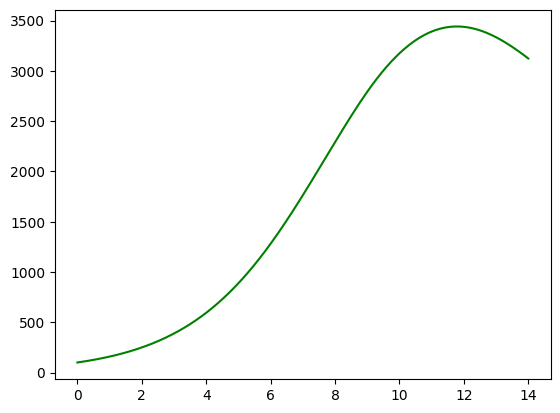

In [4]:
plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "New SIR",
    color = 'green',
)

In [5]:
scaled_sir_dead = [r * sir_model_obj.G for r in sir_model_obj.sim_r]

In [6]:
scaled_sir_vals[-1], scaled_sir_dead[-1]

(np.float64(3123.210510944207), np.float64(5076.438561088172))

# DyMES infra

In [7]:
def pandemic_func(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(- 1 * I / params['K'])) * (m_effective - n) - (params['d_0'] * n)

In [8]:
def new_run_model_for_K(K, new_c0 = 0.006, tau = 0.00001, num_days = 7):
    # Instantiate params
    model_params = {
        'm_0': 100,
        'G': 100,
        'K': K,
        'd_0': 0.2,
        'c0': 0.006, # anlogous to r_0. originally 0.006
        'c1': 1,
        'c2': 1,
        'tau': tau,
        '<n>_(t-1)': 0,
        'm_(t-1)': 100, # should be set to the same value as m_0
        'h': 1,
    }
    initial_infected = 100

    pandemic_dymes = model(initial_infected, model_params, pandemic_func, 'G')

    pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
    print("Steady state c0:", pandemic_dymes.params['c0'])

    pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
    print("Updated c0:", pandemic_dymes.params['c0'])
    pandemic_dymes.update(num_days, dt = tau)

    return pandemic_dymes

In [9]:
from dyMES.model_k_inf import model as model_k_inf

In [10]:
def pandemic_func_K_inf(n, I, params):
    m_effective = (params['m_(t-1)'] - params['c1'] * params['tau'] * params['c0'] * params['m_(t-1)'] * params['<n>_(t-1)'])

    return (params['c0'] * params['h'] * n * np.exp(0)) * (m_effective - n) - (params['d_0'] * n)

In [11]:
def new_run_model_for_K_inf(new_c0 = 0.006, tau = 0.00001, num_days = 7):
  # Instantiate params
  model_params = {
    'm_0': 100,
    'G': 100,
    # 'K': K,
    'd_0': 0.2,
    'c0': 0.006, # anlogous to r_0. originally 0.006
    'c1': 1,
    'c2': 1,
    'tau': tau,
    '<n>_(t-1)': 0,
    'm_(t-1)': 100, # should be set to the same value as m_0
    'h': 1,
  }
  initial_infected = 100

  pandemic_dymes = model_k_inf(initial_infected, model_params, pandemic_func_K_inf, 'G')

  pandemic_dymes.update_param('c0', pandemic_dymes.find_steady_state_params('c0'))
  print("Steady state c0:", pandemic_dymes.params['c0'])

  pandemic_dymes.update_param('c0', new_c0 / model_params['G'])
  print("Updated c0:", pandemic_dymes.params['c0'])
  pandemic_dymes.update(num_days, dt = tau)

  return pandemic_dymes

# Test DyMES

# K = 100

In [12]:
non_dec_c0_K_100 = new_run_model_for_K(100, new_c0 = 0.67, num_days = 14)

Steady state c0: 0.005604705124788955
Updated c0: 0.0067
1e-05
Error: 1.107531810370609e-16
1.0000003909535624 [0.69314718 0.        ] 1.0000003909535624 2.0000003909535264
Determinant: 7347.955657848612
Determinant: 7353.991217526979
Determinant: 7360.018158760559
Determinant: 7366.036485467465
Determinant: 7372.046201629822
Determinant: 7378.047311293171
Determinant: 7384.039818566141
Determinant: 7390.023727620031
Determinant: 7395.999042688471
Determinant: 7401.965768066845
0.09999999999999393
Error: 1.077309962259458e-08
1.0038614829365895 [6.91222202e-01 3.52921875e-08] 1.0038614829365895 2.0038614825865886
Determinant: 7407.923908111855
Determinant: 7413.873467241407
Determinant: 7419.814449933802
Determinant: 7425.746860727532
Determinant: 7431.670704220916
Determinant: 7437.5859850715005
Determinant: 7443.492707995837
Determinant: 7449.390877768981
Determinant: 7455.280499224073
Determinant: 7461.161577252095
0.20000000000005924
Error: 4.194137681648036e-08
1.0076278915386083 

In [13]:
non_dec_c0_K_100.states[7 * (10 ** 5) - 1]

np.float64(111.41114911037829)

In [14]:
non_dec_c0_K_100.states[-1]

np.float64(109.55343191123775)

In [15]:
non_dec_c0_K_100.num_dead[-1]

np.float64(306.192493981439)

In [16]:
non_dec_c0_K_100.num_dead[7 * (10 ** 5) - 1]

np.float64(150.92084120497296)

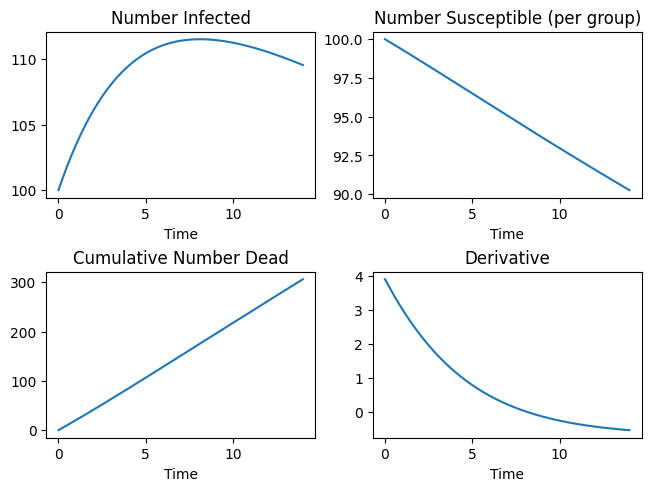

In [17]:
non_dec_c0_K_100.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.50848415 0.25855613 0.1314717  0.06685127 0.03399281
 0.01728481 0.00878905 0.00446909 0.00227246]
[1.         0.51477739 0.26499576 0.13641383 0.07022275 0.03614909
 0.01860873 0.00957935 0.00493124 0.00253849]
[1.         0.51936395 0.26973891 0.14009267 0.07275908 0.03778844
 0.01962596 0.01019301 0.00529388 0.00274945]
[1.         0.52261943 0.27313107 0.14274361 0.07460058 0.03898771
 0.02037574 0.01064876 0.00556525 0.00290851]
[1.         0.52483462 0.27545138 0.14456642 0.07587346 0.03982102
 0.02089945 0.01096876 0.00575678 0.00302136]
[1.         0.52623482 0.27692309 0.14572657 0.0766864  0.04035505
 0.02123623 0.01117525 0.0058808  0.00309468]
[1.         0.52699498 0.27772371 0.146359   0.07713046 0.04064737
 0.02142096 0.01128874 0.00594911 0.00313515]
[1.         0.52725126 0.27799389 0.14657263 0.0772806  0.0407463
 0.02148354 0.01132722 0.00597229

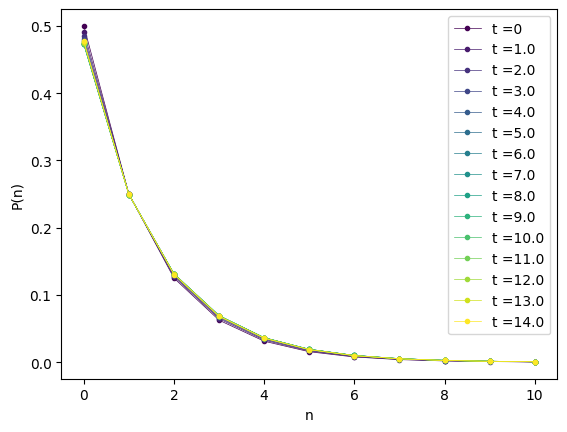

In [18]:
non_dec_c0_K_100.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 200

In [19]:
non_dec_c0_K_200 = new_run_model_for_K(200, new_c0 = 0.67, num_days = 14)

Steady state c0: 0.0033994254195476173
Updated c0: 0.0067
1e-05
Error: 3.975389733772479e-15
1.000001942472992 [0.69314718 0.        ] 1.000001942472992 2.000001942470853
Determinant: 5507.161794613134
Determinant: 5522.153673951395
Determinant: 5537.170734914063
Determinant: 5552.212905750072
Determinant: 5567.280114087839
Determinant: 5582.37228693832
Determinant: 5597.489350698672
Determinant: 5612.631231155658
Determinant: 5627.797853489399
Determinant: 5642.989142276824
0.09999999999999393
Error: 4.013316573775232e-07
1.0193983993484124 [6.83587701e-01 1.29965959e-06] 1.0193983993484124 2.0193983773936344
Determinant: 5658.205021495256
Determinant: 5673.4454145262935
Determinant: 5688.710244159304
Determinant: 5703.999432595233
Determinant: 5719.312901450232
Determinant: 5734.6505717596365
Determinant: 5750.012363981615
Determinant: 5765.39819800113
Determinant: 5780.8079931338425
Determinant: 5796.241668129812
0.20000000000005924
Error: 1.6026986557551818e-06
1.0387359907112674 [

In [20]:
non_dec_c0_K_200.states[7 * (10 ** 5) - 1]

np.float64(189.86020055777752)

In [21]:
non_dec_c0_K_200.states[-1]

np.float64(200.80152935794362)

In [22]:
non_dec_c0_K_200.num_dead[7 * (10 ** 5) - 1]

np.float64(215.3418257719797)

In [23]:
non_dec_c0_K_200.num_dead[-1]

np.float64(493.82854670460745)

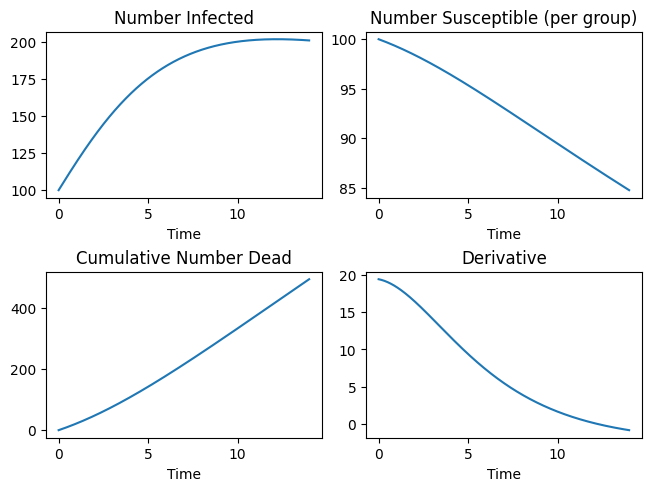

In [24]:
non_dec_c0_K_200.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.54335553 0.29523526 0.16041774 0.08716389 0.047361
 0.02573387 0.01398265 0.00759755 0.00412818]
[1.         0.5771092  0.33305507 0.1922092  0.11092574 0.0640163
 0.03694442 0.02132098 0.01230455 0.00710107]
[1.         0.60285156 0.36343007 0.21909446 0.1320815  0.07962559
 0.04800245 0.02893838 0.01744557 0.0105171 ]
[1.         0.62222885 0.38716881 0.24090769 0.1498998  0.09327204
 0.05803661 0.03611209 0.02247001 0.01398151]
[1.         0.6366685  0.40534686 0.25807167 0.16430619 0.10460865
 0.06660109 0.04240287 0.0269966  0.01718791]
[1.         0.64731333 0.41901462 0.27123384 0.17557338 0.11365107
 0.07356792 0.04762154 0.0308261  0.01995417]
[1.         0.65504469 0.42908362 0.28106904 0.18411288 0.12060225
 0.07899993 0.05174854 0.03389765 0.02220451]
[1.         0.66053168 0.43630218 0.28819152 0.19035973 0.12573872
 0.08305448 0.05486017 0.03623693 0

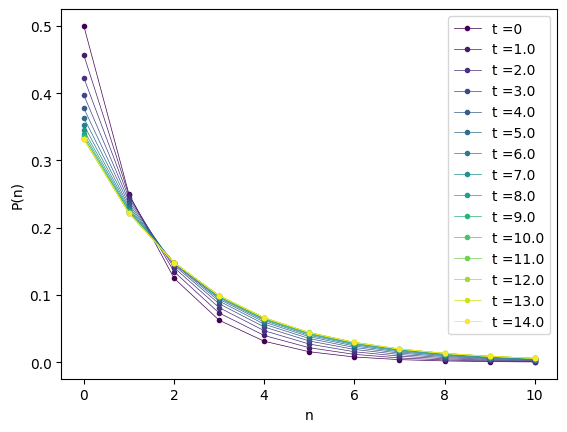

In [25]:
non_dec_c0_K_200.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 400

In [26]:
non_dec_c0_K_400 = new_run_model_for_K(400, new_c0 = 0.67, num_days = 14)

Steady state c0: 0.002647475158213124
Updated c0: 0.0067
1e-05
Error: 7.424765163744226e-15
1.0000030622876104 [0.69314718 0.        ] 1.0000030622876104 2.0000030622803653
Determinant: 5233.314610467715
Determinant: 5250.453152904772
Determinant: 5267.641974729916
Determinant: 5284.881213336204
Determinant: 5302.171006002902
Determinant: 5319.511489885765
Determinant: 5336.902802007785
Determinant: 5354.345079249471
Determinant: 5371.8384583390925
Determinant: 5389.383075843131
0.09999999999999393
Error: 7.713895104632705e-07
1.0308617009608276 [6.78065600e-01 3.49207473e-06] 1.0308617009608276 2.0308616229077923
Determinant: 5406.979068156482
Determinant: 5424.626571492744
Determinant: 5442.32572187417
Determinant: 5460.076655122032
Determinant: 5477.879506846338
Determinant: 5495.7344124362835
Determinant: 5513.64150704986
Determinant: 5531.600925604039
Determinant: 5549.6128027645545
Determinant: 5567.677272935638
0.20000000000005924
Error: 3.1394339578339368e-06
1.062189405406908 

In [27]:
non_dec_c0_K_400.states[7 * (10 ** 5) - 1]

np.float64(310.7579367601944)

In [28]:
non_dec_c0_K_400.states[-1]

np.float64(349.3408014568588)

In [29]:
non_dec_c0_K_400.num_dead[7 * (10 ** 5) - 1]

np.float64(300.9082624483245)

In [30]:
non_dec_c0_K_400.num_dead[-1]

np.float64(779.0511174833765)

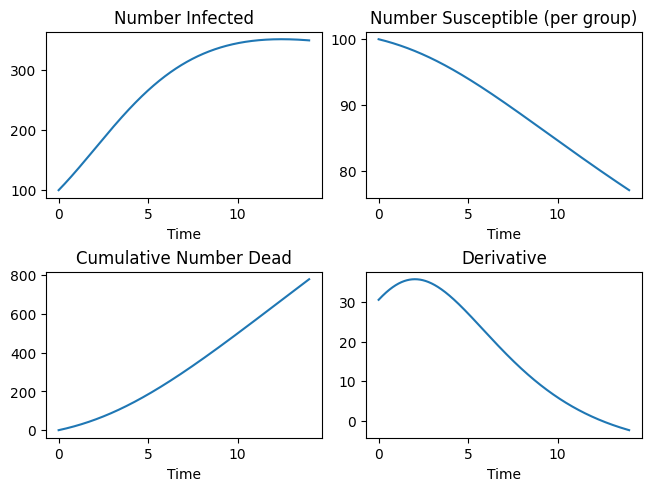

In [31]:
non_dec_c0_K_400.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.57029471 0.32523617 0.1854806  0.10577872 0.06032513
 0.03440316 0.01961998 0.0111892  0.00638116]
[1.         0.62698259 0.39310742 0.24647182 0.15453384 0.09689028
 0.06074871 0.03808853 0.02388095 0.01497302]
[1.         0.67055902 0.44964979 0.30151724 0.20218563 0.13557786
 0.09091335 0.06096308 0.04087959 0.02741237]
[1.         0.70307669 0.49431732 0.34754368 0.24435058 0.17179788
 0.12078768 0.08492351 0.05970815 0.04197974]
[1.         0.72692072 0.52841429 0.3841161  0.27922283 0.20297371
 0.14754657 0.10725534 0.0779667  0.05667609]
[1.         0.74420198 0.55383718 0.41216761 0.30673694 0.22827521
 0.16988377 0.12642865 0.09408916 0.07002194]
[1.         0.75658241 0.57241755 0.43308197 0.32766324 0.2479053
 0.18756178 0.14190685 0.10736502 0.08123118]
[1.         0.76530216 0.58568801 0.44822924 0.34303188 0.26252413
 0.20091133 0.15375884 0.11767283

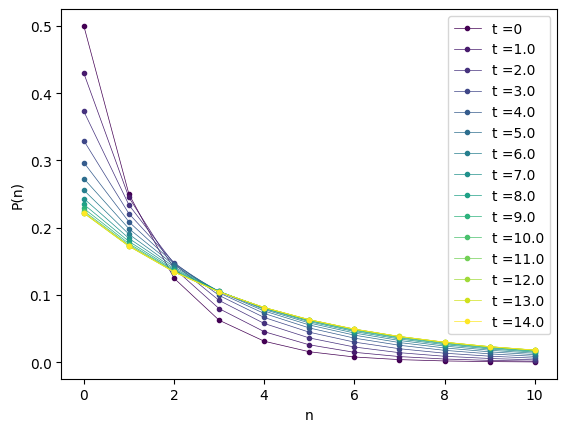

In [32]:
non_dec_c0_K_400.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 50

In [33]:
non_dec_c0_K_50 = new_run_model_for_K(50, new_c0 = 0.67, num_days = 14)

Steady state c0: 0.015235169607180651
Updated c0: 0.0067
1e-05
Error: 4.185659494365458e-16
0.999998879339356 [0.69314718 0.        ] 0.999998879339356 1.999998879339267
Determinant: 10367.457494097256
Determinant: 10351.07779858593
Determinant: 10334.749664198886
Determinant: 10318.472942493763
Determinant: 10302.247485252325
Determinant: 10286.073144482367
Determinant: 10269.949772419315
Determinant: 10253.87722152764
Determinant: 10237.855344502608
Determinant: 9837.518428500012
0.09999999999999393
Error: 4.0540804961564794e-08
0.9889511760053027 [6.98717241e-01 2.40985180e-07] 0.9889511760053027 1.9889511751361042
Determinant: 9822.003288783362
Determinant: 9806.537141429122
Determinant: 9791.119843825622
Determinant: 9775.751253590028
Determinant: 9760.431228569785
Determinant: 9745.15962684423
Determinant: 9729.936306725842
Determinant: 9714.76112676187
Determinant: 9330.062796442162
Determinant: 9315.374055439155
0.20000000000005924
Error: 1.6453836063045056e-07
0.97821182137685

In [34]:
non_dec_c0_K_50.states[7 * (10 ** 5) - 1]

np.float64(64.991904215025)

In [35]:
non_dec_c0_K_50.states[-1]

np.float64(58.19869115198852)

In [36]:
non_dec_c0_K_50.num_dead[7 * (10 ** 5) - 1]

np.float64(108.35125245778904)

In [37]:
non_dec_c0_K_50.num_dead[-1]

np.float64(193.55346294830633)

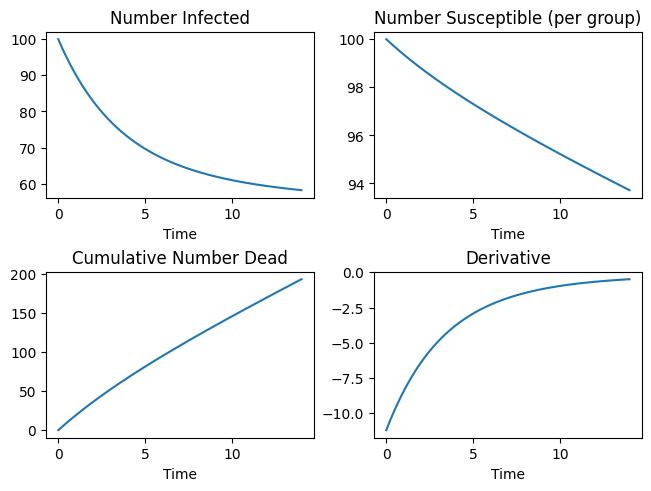

In [38]:
non_dec_c0_K_50.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.         0.47435204 0.22500986 0.10673389 0.05062944 0.02401618
 0.01139212 0.00540388 0.00256334 0.00121593]
[1.00000000e+00 4.53159181e-01 2.05353246e-01 9.30577107e-02
 4.21699574e-02 1.91097042e-02 8.65973841e-03 3.92424024e-03
 1.77830563e-03 8.05855599e-04]
[1.00000000e+00 4.35860253e-01 1.89974163e-01 8.28021899e-02
 3.60901854e-02 1.57302785e-02 6.85620378e-03 2.98834704e-03
 1.30250186e-03 5.67708875e-04]
[1.00000000e+00 4.21832024e-01 1.77942261e-01 7.50617478e-02
 3.16634514e-02 1.33566591e-02 5.63426726e-03 2.37671472e-03
 1.00257456e-03 4.22918139e-04]
[1.00000000e+00 4.10483852e-01 1.68496998e-01 6.91653012e-02
 2.83912420e-02 1.16541478e-02 4.78384024e-03 1.96368954e-03
 8.06063024e-04 3.30875938e-04]
[1.00000000e+00 4.01298895e-01 1.61040809e-01 6.46255037e-02
 2.59341461e-02 1.04073457e-02 4.17645711e-03 1.67600800e-03
 6.72580331e-04 2.69905823e-04]
[1.0000

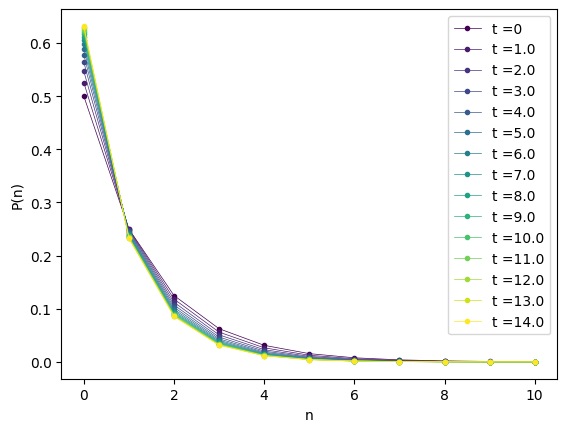

In [39]:
non_dec_c0_K_50.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 25

In [40]:
non_dec_c0_K_25 = new_run_model_for_K(25, new_c0 = 1.23, num_days = 14)

Steady state c0: 0.1125736358706427
Updated c0: 0.0123
1e-05
Error: 6.552975367024146e-16
0.999998218267872 [0.69314718 0.        ] 0.999998218267872 1.9999982182678255
Determinant: 12371.285058444191
Determinant: 12344.55502097127
Determinant: 12317.883240605843
Determinant: 12291.26970232289
Determinant: 12264.714391168658
Determinant: 11851.174733819329
Determinant: 11825.414933425685
Determinant: 11799.711405697171
Determinant: 11774.064138556667
Determinant: 11748.473119968627
0.09999999999999393
Error: 6.401833052273242e-08
0.9824170420477452 [7.02055402e-01 5.10103077e-07] 0.9824170420477452 1.9824170415759146
Determinant: 11722.938337932257
Determinant: 11323.082071557103
Determinant: 11298.31871751553
Determinant: 11273.60971716587
Determinant: 11248.955061142422
Determinant: 11224.354740084964
Determinant: 11199.808744631948
Determinant: 10813.315994493549
Determinant: 10789.518083812818
Determinant: 10765.772684304802
0.20000000000005924
Error: 2.6380311833213644e-07
0.96529

In [41]:
non_dec_c0_K_25.states[7 * (10 ** 5) - 1]

np.float64(48.718229902253476)

In [42]:
non_dec_c0_K_25.states[-1]

np.float64(43.34077502028628)

In [43]:
non_dec_c0_K_25.num_dead[7 * (10 ** 5) - 1]

np.float64(91.54321901277628)

In [44]:
non_dec_c0_K_25.num_dead[-1]

np.float64(154.82688327372227)

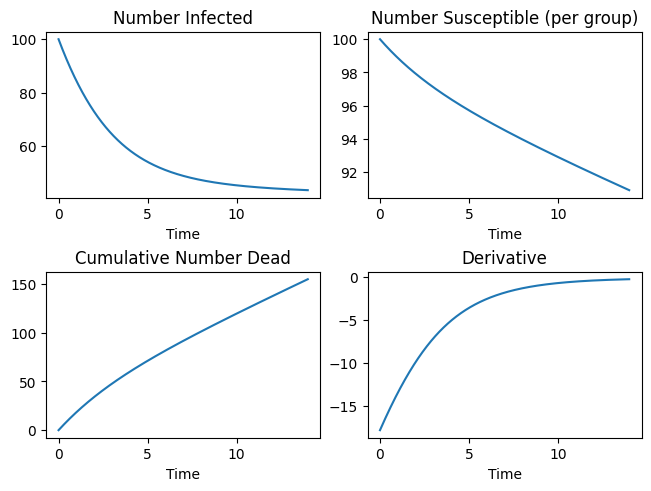

In [45]:
non_dec_c0_K_25.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 4.57748833e-01 2.09533995e-01 9.59139423e-02
 4.39044957e-02 2.00972320e-02 9.19948471e-03 4.21105350e-03
 1.92760489e-03 8.82358918e-04]
[1.00000000e+00 4.21258698e-01 1.77458893e-01 7.47561046e-02
 3.14916607e-02 1.32661368e-02 5.58847594e-03 2.35419432e-03
 9.91724939e-04 4.17772808e-04]
[1.00000000e+00 3.91439507e-01 1.53224892e-01 5.99782803e-02
 2.34778708e-02 9.19016738e-03 3.59739519e-03 1.40816288e-03
 5.51210711e-04 2.15765706e-04]
[1.00000000e+00 3.68109709e-01 1.35504765e-01 4.98806253e-02
 1.83615456e-02 6.75906472e-03 2.48807805e-03 9.15885998e-04
 3.37146662e-04 1.24107016e-04]
[1.00000000e+00 3.50395613e-01 1.22777096e-01 4.30205629e-02
 1.50742202e-02 5.28194239e-03 1.85077020e-03 6.48502082e-04
 2.27232416e-04 7.96212943e-05]
[1.00000000e+00 3.37183925e-01 1.13693012e-01 3.83354642e-02
 1.29261065e-02 4.35847718e-03 1.46960923e-03 4.95528929e-0

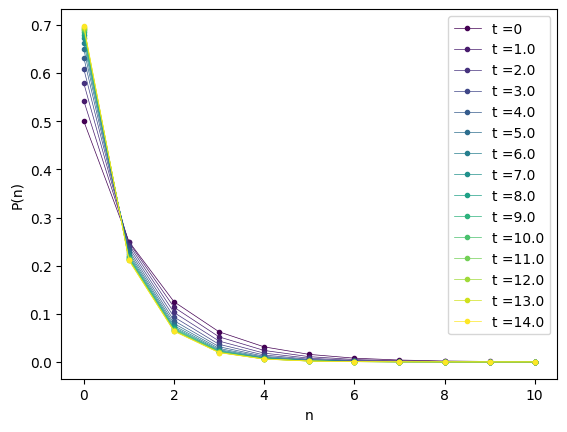

In [46]:
non_dec_c0_K_25.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = 10

In [47]:
non_dec_c0_K_10 = new_run_model_for_K(10, new_c0 = 0.67, tau = 0.00001, num_days = 14)

Steady state c0: 45.43667680990588
Updated c0: 0.0067
1e-05
Error: 7.024264644602398e-16
0.9999980000300208 [0.69314718 0.        ] 0.9999980000300208 1.9999980000300208
Determinant: 13104.785165279654
Determinant: 13078.609973892993
Determinant: 13052.486778866709
Determinant: 13026.415473312396
Determinant: 13000.395950527101
Determinant: 12587.060112219207
Determinant: 12561.9169105882
Determinant: 12536.823627438518
Determinant: 12511.780159851938
Determinant: 12486.786405086903
0.09999999999999393
Error: 6.85115979798131e-08
0.980199221793735 [7.03196009e-01 6.09076120e-07] 0.980199221793735 1.9801992217928763
Determinant: 12086.034875534602
Determinant: 12061.890257795545
Determinant: 12037.793546733104
Determinant: 12013.74464326643
Determinant: 11989.74344848307
Determinant: 11601.274230386354
Determinant: 11578.095659095661
Determinant: 11554.963047048153
Determinant: 11531.876298872163
Determinant: 11508.835319355974
0.20000000000005924
Error: 2.8423962272970805e-07
0.9607910

In [48]:
non_dec_c0_K_10.states[7 * (10 ** 5) - 1]

np.float64(26.59982189444794)

In [49]:
non_dec_c0_K_10.states[-1]

np.float64(14.085940480857388)

In [50]:
non_dec_c0_K_10.num_dead[7 * (10 ** 5) - 1]

np.float64(75.98446198130645)

In [51]:
non_dec_c0_K_10.num_dead[-1]

np.float64(101.73967632796811)

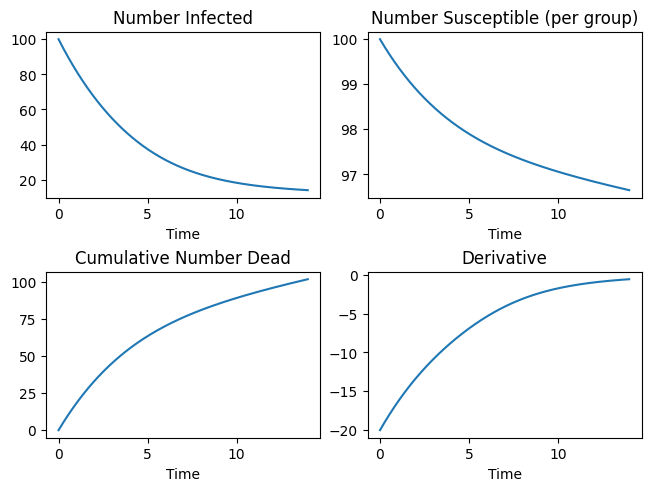

In [52]:
non_dec_c0_K_10.graph_v2()

[1.         0.5        0.25       0.125      0.0625     0.03125
 0.015625   0.0078125  0.00390625 0.00195312]
[1.00000000e+00 4.50179052e-01 2.02661179e-01 9.12338174e-02
 4.10715535e-02 1.84895530e-02 8.32360945e-03 3.74711461e-03
 1.68687250e-03 7.59394665e-04]
[1.00000000e+00 4.01412188e-01 1.61131745e-01 6.46802463e-02
 2.59634392e-02 1.04220410e-02 4.18353428e-03 1.67932165e-03
 6.74100180e-04 2.70592029e-04]
[1.00000000e+00 3.54773474e-01 1.25864218e-01 4.46532862e-02
 1.58418016e-02 5.62025102e-03 1.99391600e-03 7.07388514e-04
 2.50962684e-04 8.90349044e-05]
[1.00000000e+00 3.11363809e-01 9.69474220e-02 3.01859190e-02
 9.39880290e-03 2.92644715e-03 9.11189761e-04 2.83711526e-04
 8.83375056e-05 2.75051037e-05]
[1.00000000e+00 2.72235567e-01 7.41122057e-02 2.01759793e-02
 5.49261953e-03 1.49528653e-03 4.07070222e-04 1.10819008e-04
 3.01688803e-05 8.21304373e-06]
[1.00000000e+00 2.38201836e-01 5.67401181e-02 1.35156020e-02
 3.21944179e-03 7.66877133e-04 1.82671597e-04 4.35127257e-0

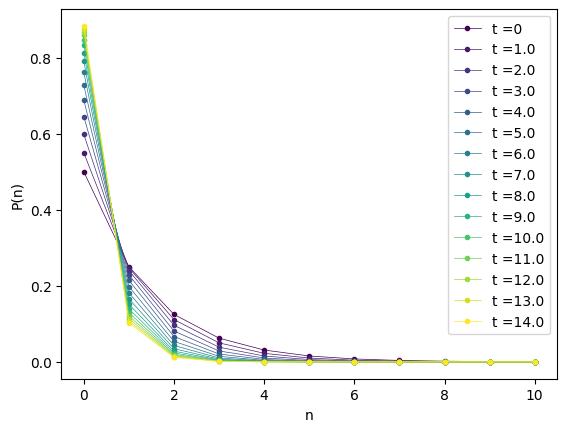

In [53]:
non_dec_c0_K_10.graph_probability_distributions(x_upper_bound = 10, interval = 1, legend = True)

# K = inf

In [54]:
non_dec_c0_K_inf = new_run_model_for_K_inf(tau = 0.00001, new_c0 = 0.67, num_days = 14)

Steady state c0: 0.0020618557139304022
Updated c0: 0.0067
1e-05
Error: 3.883681196996912e-15
1.000004499622743 [0.69314718 0.        ] 1.000004499622743 2.0000044996056667
Determinant: 6193.039067586214
Determinant: 6222.0069245602745
Determinant: 6251.109650549182
Determinant: 6280.34787693091
Determinant: 6309.722238182945
Determinant: 6339.233371900102
Determinant: 6368.881918812189
Determinant: 6398.668522802173
Determinant: 6428.593830924263
Determinant: 6458.658493421953
0.09999999999999393
Error: 3.9929251658207855e-07
1.0459677445228082 [6.70927714e-01 6.56475843e-06] 1.0459677445228082 2.045967547596474
Determinant: 6488.863163746698
Determinant: 6519.208498576317
Determinant: 6549.695157833561
Determinant: 6580.32380470507
Determinant: 6611.095105660207
Determinant: 6642.009730470355
Determinant: 6673.068352227814
Determinant: 6704.271647365519
Determinant: 6735.6202956762745
Determinant: 6767.114980332743
0.20000000000005924
Error: 1.5281680945755154e-06
1.0939277693428733 [

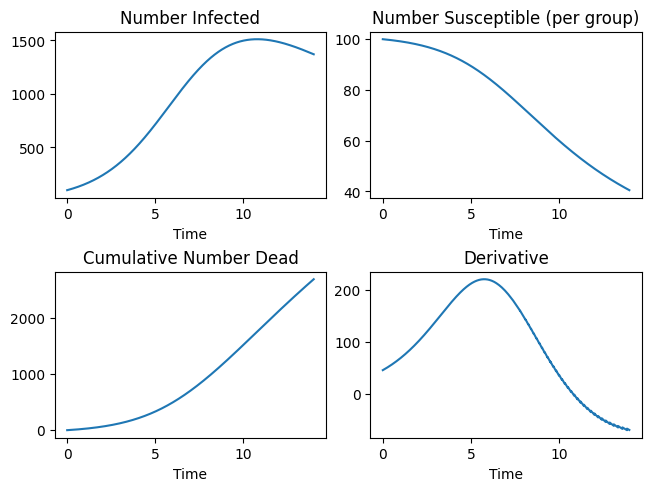

In [55]:
non_dec_c0_K_inf.graph_v2()

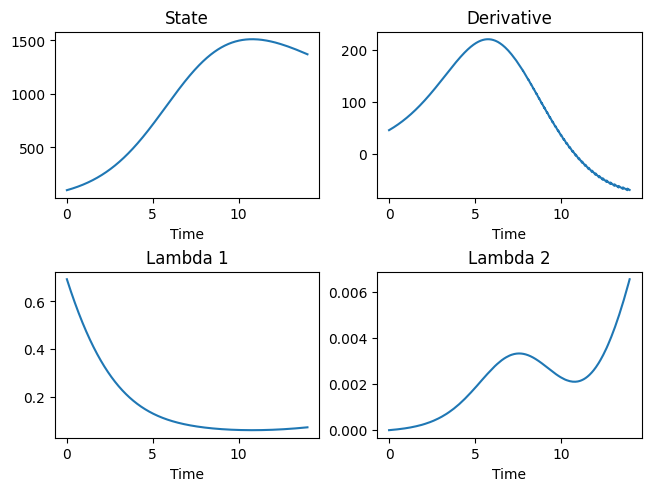

In [56]:
non_dec_c0_K_inf.graph()

In [57]:
non_dec_c0_K_inf.params

{'m_0': 100,
 'G': 100,
 'd_0': 0.2,
 'c0': 0.0067,
 'c1': 1,
 'c2': 1,
 'tau': 1e-05,
 '<n>_(t-1)': np.float64(13.707218625465682),
 'm_(t-1)': np.float64(40.505411661098606),
 'h': 1,
 'I_(t-1)': np.float64(1370.7225647429793)}

In [58]:
non_dec_c0_K_inf.lambdas[-1]

array([0.07318676, 0.00654363])

In [59]:
m_effective = non_dec_c0_K_inf.params['m_(t-1)'] - (
    non_dec_c0_K_inf.params['tau'] * 
    non_dec_c0_K_inf.params['c1'] * 
    non_dec_c0_K_inf.params['c0'] * 
    non_dec_c0_K_inf.params['m_(t-1)'] * 
    non_dec_c0_K_inf.params['<n>_(t-1)'])
Z = rf.R_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])

In [60]:
m_effective, Z

(np.float64(40.50537446159088), np.float64(13.57600160774933))

In [61]:
n_mean = rf.Rn_mean(non_dec_c0_K_inf.func, non_dec_c0_K_inf.states[-1], m_effective, non_dec_c0_K_inf.params, non_dec_c0_K_inf.lambdas[-1])/Z

In [62]:
n_mean

np.float64(11.226334112840583)

In [63]:
non_dec_c0_K_inf.states[-1]

np.float64(1370.7218625465682)

In [64]:
n_mean * non_dec_c0_K_inf.params['G']

np.float64(1122.6334112840582)

In [65]:
(non_dec_c0_K_inf.states[-1] - n_mean * non_dec_c0_K_inf.params['G']) ** 2

np.float64(61547.879649830815)

In [66]:
# It's not lambdas being weird it's just straight up not being constrained

# Graphing stuff

In [67]:
list_of_models = [non_dec_c0_K_10,
                  non_dec_c0_K_25,
                  non_dec_c0_K_50,
                  non_dec_c0_K_100,
                  non_dec_c0_K_200,
                  non_dec_c0_K_400,
                  non_dec_c0_K_inf,]
labels = ["K = 10", "K = 25", "K = 50", "K = 100", "K = 200", "K = 400", "K = inf"]
K_vals = [10, 25, 50, 100, 200, 400]

K_cmap = plt.get_cmap('plasma')
K_norm = plt.Normalize(vmin=0, vmax=len(list_of_models))

/Users/meilinyen/Desktop/dymes_052026/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


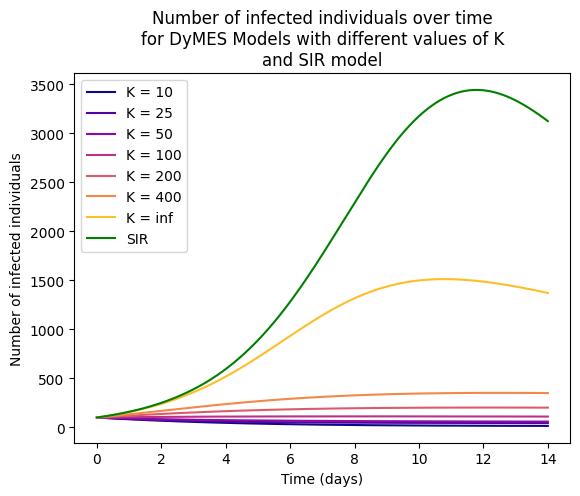

In [68]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].states[j] for j in range(len(list_of_models[i].states))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_vals[j] for j in range(len(scaled_sir_vals))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Number of infected individuals")
plt.title("Number of infected individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()
plt.show()

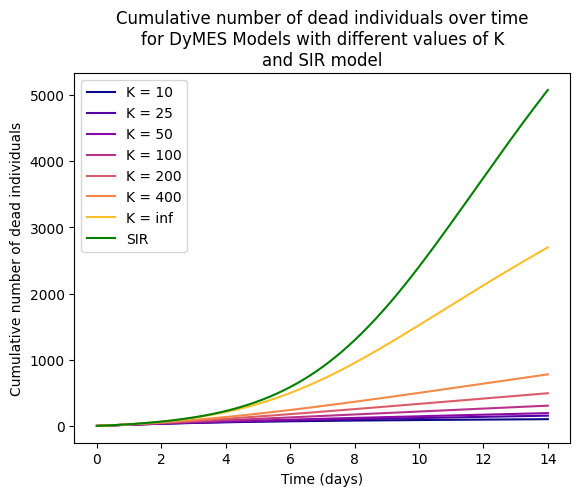

In [69]:
for i in range(len(list_of_models)):
  plt.plot(list_of_models[i].time,
           [list_of_models[i].num_dead[j] for j in range(len(list_of_models[i].num_dead))],
           label = labels[i],
           color = K_cmap(K_norm(i))
  )

plt.plot(
    sir_model_obj.t,
    [scaled_sir_dead[j] for j in range(len(scaled_sir_dead))],
    label = "SIR",
    color = 'green',
)

# plt.yscale('log')
plt.xlabel("Time (days)")
plt.ylabel("Cumulative number of dead individuals")
plt.title("Cumulative number of dead individuals over time\nfor DyMES Models with different values of K\nand SIR model")
plt.legend()
plt.show()

In [70]:
x_upper_bound = 10

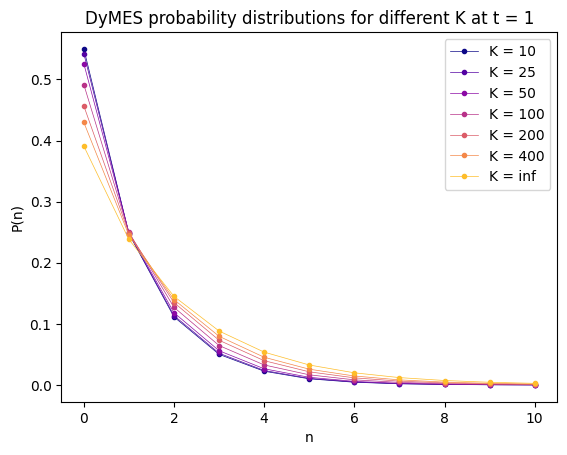

In [71]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 1")
plt.legend()
plt.show()

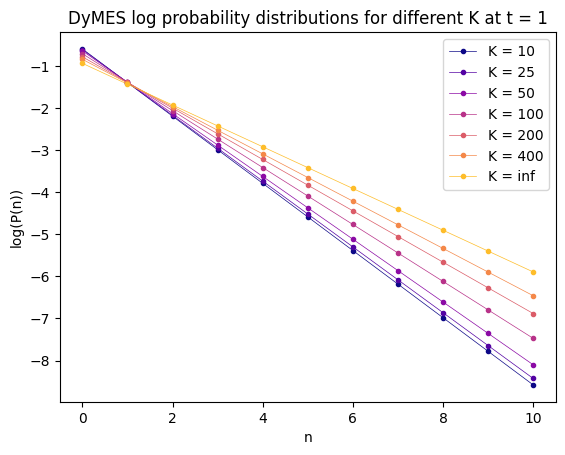

In [72]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[1.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 1")
plt.legend()
plt.show()

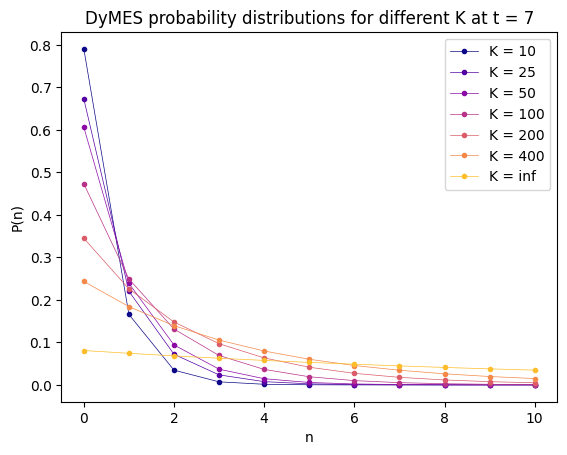

In [73]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 7")
plt.legend()
plt.show()

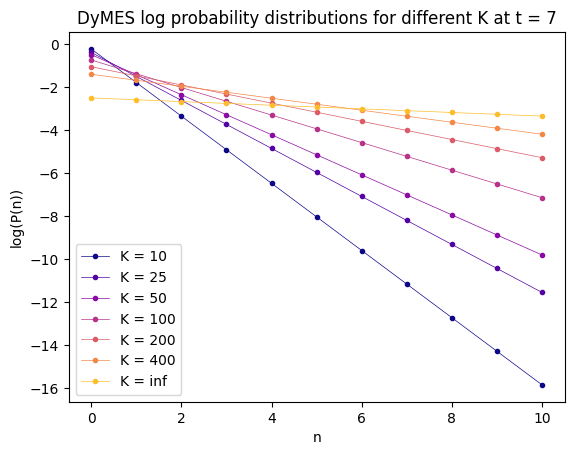

In [74]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[7.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 7")
plt.legend()
plt.show()

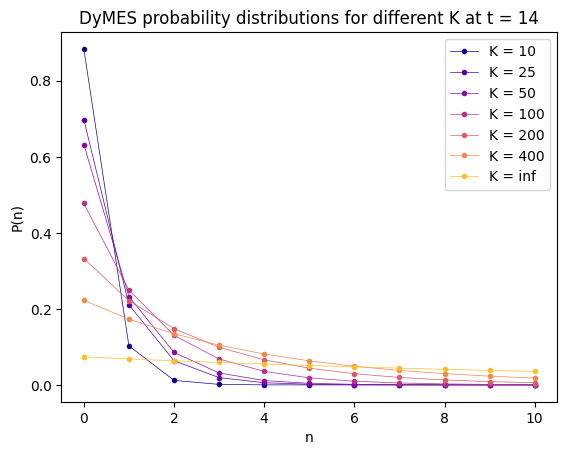

In [75]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           normalized_pd[0:x_upper_bound+1],
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("P(n)")
plt.title("DyMES probability distributions for different K at t = 14")
plt.legend()
plt.show()

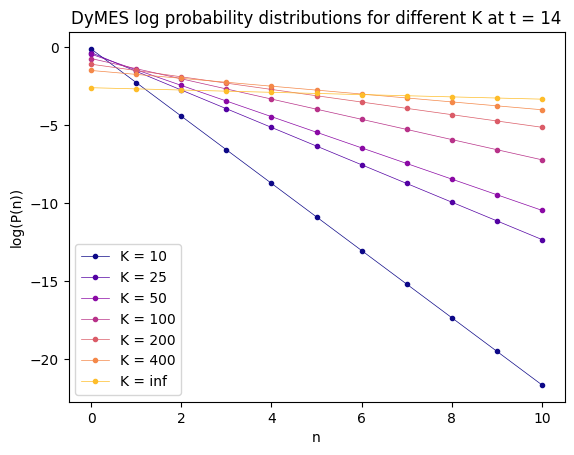

In [76]:
for i in range(len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()

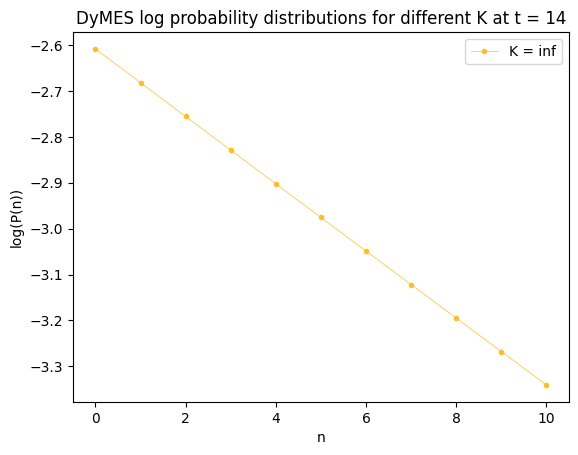

In [77]:
for i in range(len(list_of_models)-1, len(list_of_models)):
  prob_dist = list_of_models[i].probability_distributions[14.0]
  normalized_pd = prob_dist / sum(prob_dist)

  x_axis = np.arange(0, x_upper_bound + 1)

  plt.plot(x_axis,
           np.log(normalized_pd[0:x_upper_bound+1]),
           label = labels[i],
           color = K_cmap(K_norm(i)),
           linewidth=0.5,
            marker = 'o',
            markersize = 3
  )

plt.xlabel("n")
plt.ylabel("log(P(n))")
plt.title("DyMES log probability distributions for different K at t = 14")
plt.legend()
plt.show()